In [19]:
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
from shapely.geometry import Polygon

In [20]:
taxi_data_processed = pd.read_parquet(
    "../data/taxi_data_processed.parquet"
)

#final_grid = pd.read_parquet(
#    "../data/final_grid.parquet"
#)

## Demand Analysis

In [21]:
spatial_demand = (
    taxi_data_processed
    .groupby("h3_index_pickup")
    .size()
    .reset_index(name="trip_count")
)
spatial_demand

,h3_index_pickup,trip_count
0,882664191dfffff,5
1,8826641937fffff,5
2,8826641963fffff,7
3,8826641b27fffff,2
4,8826641b29fffff,7
...,...,...
355,88275936b1fffff,111
356,88275936bbfffff,29
357,88275936cbfffff,1
358,88275936d3fffff,3


In [22]:
top_demand = (
    spatial_demand
    .sort_values("trip_count", ascending=False)
    .head(20)
)

top_demand

,h3_index_pickup,trip_count
351,88275934edfffff,1192882
70,882664c1e3fffff,866703
66,882664c1adfffff,739773
64,882664c1a9fffff,675702
69,882664c1e1fffff,583740
74,882664c1ebfffff,354379
65,882664c1abfffff,263799
67,882664c1b1fffff,232285
6,8826645219fffff,172945
73,882664c1e9fffff,163129


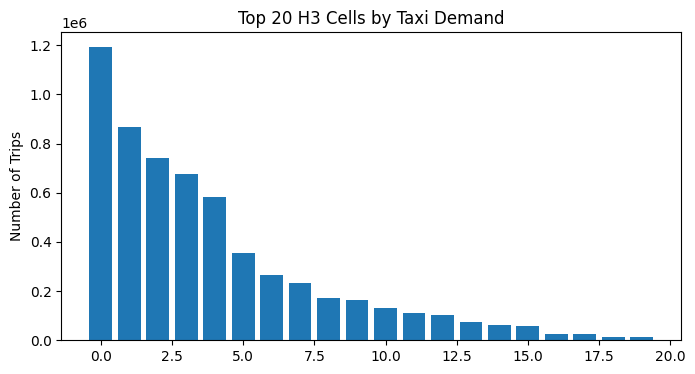

In [23]:
plt.figure(figsize=(8,4))

plt.bar(
    range(len(top_demand)),
    top_demand["trip_count"]
)

plt.title("Top 20 H3 Cells by Taxi Demand")
plt.ylabel("Number of Trips")

plt.show()

In [24]:
spatial_stats_h8 = (
    taxi_data_processed
    .groupby("h3_index_pickup")
    .agg(
        trip_count=("h3_index_pickup", "size"),
        avg_trip_length=("Trip Miles", "mean"),
        avg_price=("Trip Total", "mean"),
    )
    .reset_index()
)
spatial_stats_h8["geometry"] = [
    Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(h)])
    for h in spatial_stats_h8["h3_index_pickup"]
]

spatial_stats_h7 = (
    taxi_data_processed
    .groupby("h3_7_index_pickup")
    .agg(
        trip_count=("h3_7_index_pickup", "size"),
        avg_trip_length=("Trip Miles", "mean"),
        avg_price=("Trip Total", "mean"),
    )
    .reset_index()
)
spatial_stats_h7["geometry"] = [
    Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(h)])
    for h in spatial_stats_h7["h3_7_index_pickup"]
]

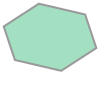

In [25]:
gdf_spatial_h8 = gpd.GeoDataFrame(
    spatial_stats_h8,
    geometry="geometry",
    crs="EPSG:4326"
)

gdf_spatial_h7 = gpd.GeoDataFrame(
    spatial_stats_h7,
    geometry="geometry",
    crs="EPSG:4326"
)

gdf_spatial_h7.geometry.iloc[0]

In [26]:
gdf_spatial_h7.total_bounds

array([-87.92947302,  41.64008885, -87.51550479,  42.03305375])

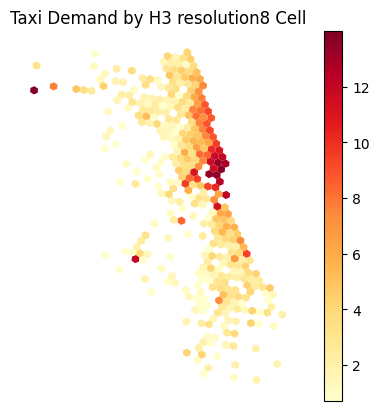

In [27]:
gdf_spatial_h8["log_demand"] = np.log1p(
    gdf_spatial_h8["trip_count"]
)

fig, ax = plt.subplots()

gdf_spatial_h8.plot(
    column="log_demand",
    cmap="YlOrRd",
    legend=True,
    ax=ax
)

ax.set_title("Taxi Demand by H3 resolution8 Cell")
ax.axis("off")

plt.show()

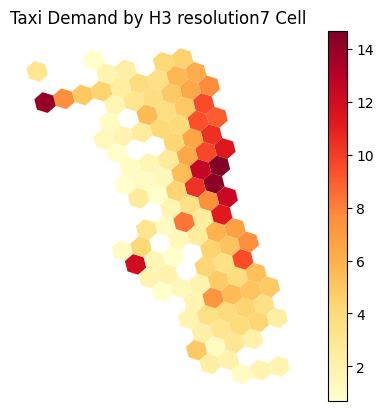

In [28]:
gdf_spatial_h7["log_demand"] = np.log1p(
    gdf_spatial_h7["trip_count"]
)

fig, ax = plt.subplots()

gdf_spatial_h7.plot(
    column="log_demand",
    cmap="YlOrRd",
    legend=True,
    ax=ax
)

ax.set_title("Taxi Demand by H3 resolution7 Cell")
ax.axis("off")

plt.show()

In [29]:
m = folium.Map(
    location=[41.88, -87.63],
    zoom_start=11
)

folium.GeoJson(
    gdf_spatial_h8,
    style_function=lambda x: {
        "fillOpacity": 0.6,
        "weight": 0.2
    }
).add_to(m)

m.save("../docs/maps/hexagon_8_map.html")

In [30]:
m = folium.Map(
    location=[41.88, -87.63],
    zoom_start=11,
    tiles="CartoDB positron"
)

folium.Choropleth(
    geo_data=gdf_spatial_h8,
    data=gdf_spatial_h8,
    columns=["h3_index_pickup", "log_demand"],
    key_on="feature.properties.h3_index_pickup",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    legend_name="log Number of Trips"
).add_to(m)

m.save("../docs/maps/hexagon_8_log_demand_map.html")

In [31]:
m = folium.Map(
    location=[41.88, -87.63],
    zoom_start=11,
    tiles="CartoDB positron"
)

folium.Choropleth(
    geo_data=gdf_spatial_h7,
    data=gdf_spatial_h7,
    columns=["h3_7_index_pickup", "log_demand"],
    key_on="feature.properties.h3_7_index_pickup",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    legend_name="log Number of Trips"
).add_to(m)

m.save("../docs/maps/hexagon_7_log_demand_map.html")

In [32]:
m = folium.Map(
    location=[41.88, -87.63],
    zoom_start=11,
    tiles="CartoDB positron"
)

folium.Choropleth(
    geo_data=gdf_spatial_h8,
    data=gdf_spatial_h8,
    columns=["h3_index_pickup", "avg_trip_length"],
    key_on="feature.properties.h3_index_pickup",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    legend_name="avg trip length"
).add_to(m)

m.save("../docs/maps/hexagon_8_avg_trip_length_map.html")

In [33]:
m = folium.Map(
    location=[41.88, -87.63],
    zoom_start=11,
    tiles="CartoDB positron"
)

folium.Choropleth(
    geo_data=gdf_spatial_h7,
    data=gdf_spatial_h7,
    columns=["h3_7_index_pickup", "avg_trip_length"],
    key_on="feature.properties.h3_7_index_pickup",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    legend_name="avg trip length"
).add_to(m)

m.save("../docs/maps/hexagon_7_avg_trip_length_map.html")

In [34]:
taxi_data_processed["Pickup Census Tract"].head(5)

0    17031833000
1    17031833000
2    17031833000
3    17031980000
4    17031980000
Name: Pickup Census Tract, dtype: int64

In [35]:
tract_demand = (
    taxi_data_processed
    .groupby("Pickup Census Tract")
    .size()
    .reset_index(name="trip_count")
)